In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.transforms import offset_copy

In [10]:
# figure save directory
save_dir = "../../img/heatmaps"
os.makedirs(save_dir, exist_ok=True)

# input file
input_file = '../../results/barseq/combined_grouped-barcodes_241120.csv'
df = pd.read_csv(input_file)

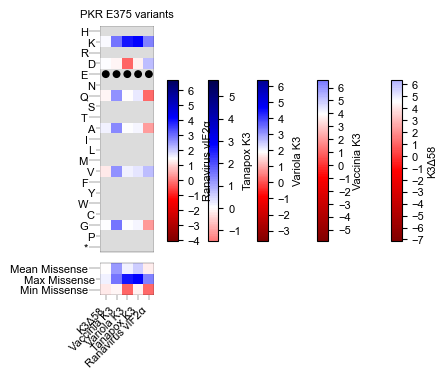

(<Figure size 600x350 with 6 Axes>,
 <Axes: title={'center': 'PKR E375 variants'}>)

In [18]:
# plot parameters
plt.rcParams['font.family'] = 'Arial'

def custom_cmap(cmap_name, center, vmin, vmax):
    """Pulled from seaborn matrix.py to center cmap on WT value"""
    cmap = mpl.colormaps[cmap_name]
    under = cmap(-np.inf)
    over = cmap(np.inf)
    under_set = under != cmap(0)
    over_set = over != cmap(cmap.N - 1)

    vrange = max(vmax - center, center - vmin)
    normlize = mpl.colors.Normalize(center - vrange, center + vrange)
    cmin, cmax = normlize([vmin, vmax])
    cc = np.linspace(cmin, cmax, 256)
    cmap = mpl.colors.ListedColormap(cmap(cc))
    cmap.set_bad(color='gainsboro')
    if under_set:
        cmap.set_under(under)
    if over_set:
        cmap.set_over(over)

    return cmap

['K3Δ58', 'VACV K3', 'VARV C3', 'TPV K3', 'MYXV M156R', 'RCVZ vIF2α']
k3_names = ['K3Δ58', 'Vaccinia K3', 'Variola K3', 'Tanapox K3', 'Myxoma K3', 'Ranavirus K3']

def plot_residue_miniheatmap(
    df,
    focus_site,
    save_dir=save_dir,
    conditions=('K3Δ58', 'VACV K3', 'VARV C3', 'TPV K3', 'RCVZ vIF2α'),
    condition_names=('K3Δ58', 'Vaccinia K3', 'Variola K3', 'Tanapox K3', 'Ranavirus vIF2α'),
    cmap_color='seismic_r',
    scale_scope='condition',
    show_wt_circles=True,
    stagger_labels=True,
    font_size=8,
):
    
    conditions = list(conditions)
    condition_names = list(condition_names)

    # amino-acid row order (same as the big heatmaps)
    aa_list = ['H', 'K', 'R', 'D', 'E', 'N', 'Q', 'S', 'T', 'A', 'I',
               'L', 'M', 'V', 'F', 'Y', 'W', 'C', 'G', 'P', '*']
    aa_no_stops = [a for a in aa_list if a != '*']
    summary_rows = ['Mean Missense', 'Max Missense', 'Min Missense']
    GAP_ROW = '__row_gap__'

    site_df = df.query('site == @focus_site')
    if site_df.empty:
        raise ValueError(f'No rows found for site {focus_site}')
    wt_aa = site_df['wt_aa'].dropna().iloc[0]

    # --- Value matrix: rows = AA variants, cols = virus conditions ---
    data = pd.DataFrame(index=aa_list, columns=conditions, dtype=float)
    for cond in conditions:
        s = (site_df.query('k3 == @cond and pkr != "PKR-WT"')
                    .set_index('var_aa')['auc_mean'])
        for aa in aa_list:
            data.loc[aa, cond] = s.get(aa, np.nan)

    # --- Summary rows (missense only, WT row is NaN so it's skipped) ---
    missense = data.loc[aa_no_stops]
    summary = pd.DataFrame(index=summary_rows, columns=conditions, dtype=float)
    summary.loc['Mean Missense'] = missense.mean(axis=0, skipna=True)
    summary.loc['Max Missense'] = missense.max(axis=0, skipna=True)
    summary.loc['Min Missense'] = missense.min(axis=0, skipna=True)

    # --- Stack with a white gap row above the summaries ---
    gap = pd.DataFrame(index=[GAP_ROW], columns=conditions, dtype=float)
    full = pd.concat([data, gap, summary])
    row_labels = list(full.index)
    n_rows, n_cols = len(row_labels), len(conditions)

    # --- Per-virus colormap + normalization (each column on its own scale) ---
    cmaps, norms, scale = {}, {}, {}
    for cond in conditions:
        cond_all = df.query('k3 == @cond')
        center = cond_all.query('pkr == "PKR-WT"')['auc_mean'].iloc[0]
        if scale_scope == 'site':
            vmin = np.nanmin(data[cond].values.astype(float))
            vmax = np.nanmax(data[cond].values.astype(float))
        else:  # 'condition' -> matches the full-length heatmaps
            vmin = cond_all['auc_mean'].min()
            vmax = cond_all['auc_mean'].max()
        cmaps[cond] = custom_cmap(cmap_color, center, vmin, vmax)  # your existing fn
        norms[cond] = mcolors.Normalize(vmin, vmax)
        scale[cond] = (vmin, vmax)

    # --- Figure ---
    plt.rcParams['font.family'] = 'Arial'
    fig, ax = plt.subplots(figsize=(6,3.5))
    gainsboro = mcolors.to_rgba('gainsboro')

    # --- Draw each cell, colored on its own column's scale ---
    for i, rlabel in enumerate(row_labels):
        for j, cond in enumerate(conditions):
            if rlabel == GAP_ROW:
                color = (1, 1, 1, 1)                       # white spacer
            else:
                val = full.loc[rlabel, cond]
                color = gainsboro if pd.isna(val) else cmaps[cond](norms[cond](val))
            ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor=color,
                                       edgecolor='none', zorder=1))

    ax.set_xlim(0, n_cols)
    ax.set_ylim(n_rows, 0)   # row 0 at the top
    ax.set_aspect('equal')

    # --- WT identity circles (WT-AA row, one per virus column) ---
    if show_wt_circles and wt_aa in row_labels:
        wt_i = row_labels.index(wt_aa)
        for j in range(n_cols):
            ax.add_patch(plt.Circle((j + 0.5, wt_i + 0.5), 0.3,
                                    color='black', fill=True, zorder=4))

    # --- Section outlines: AA block + summary block (0.2 pt) ---
    gap_i = row_labels.index(GAP_ROW)
    for (r0, r1) in [(0, gap_i - 1), (gap_i + 1, n_rows - 1)]:
        ax.add_patch(plt.Rectangle((0, r0), n_cols, (r1 - r0 + 1),
                                   fill=False, edgecolor='black',
                                   linewidth=0.2, zorder=5))
    for spine in ax.spines.values():
        spine.set_visible(False)

    # --- Y ticks (AA + summary labels, gap row hidden) ---
    y_labels = ['' if r == GAP_ROW else r for r in row_labels]
    ax.set_yticks(np.arange(n_rows) + 0.5)
    ax.set_yticklabels(y_labels, rotation=0, fontsize=font_size)
    ax.tick_params(axis='both', which='both', width=0.25)

    if stagger_labels:
        summary_offsets = {'Mean Missense': -2, 'Max Missense': 3, 'Min Missense': -2}
        aa_counter = 0
        for i, tick in enumerate(ax.yaxis.get_major_ticks()):
            rlabel = row_labels[i]
            if rlabel == GAP_ROW:
                tick.tick1line.set_markersize(0)
                continue
            tick.tick1line.set_markersize(8 if i % 2 == 0 else 3)
            dx = None
            if rlabel in aa_list:
                dx = -2 if aa_counter % 2 == 0 else 3
                aa_counter += 1
            elif rlabel in summary_offsets:
                dx = summary_offsets[rlabel]
            if dx is not None:
                lab = tick.label1
                lab.set_transform(offset_copy(lab.get_transform(), fig=fig,
                                              x=dx, y=0, units='points'))

    # --- X ticks (virus names) ---
    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_xticklabels(condition_names, rotation=45, ha='right', fontsize=font_size)
    ax.set_title(f'PKR {wt_aa}{focus_site} variants', fontsize=font_size, pad=6)

    # --- One colorbar per virus (each shows its own scale) ---
    for cond, name in zip(conditions, condition_names):
        vmin, vmax = scale[cond]
        ticks = np.arange(np.ceil(vmin), np.floor(vmax) + 1, 1)
        sm = mpl.cm.ScalarMappable(cmap=cmaps[cond], norm=norms[cond])
        sm.set_array([])
        cb = fig.colorbar(sm, ax=ax, fraction=0.12, pad=0.06,
                          aspect=15, shrink=0.6, ticks=ticks)
        cb.ax.tick_params(labelsize=font_size)
        cb.set_label(name, rotation=90, fontsize=font_size, labelpad=2)

    # --- Save ---
    plot_name = f'residue-miniheatmap_{wt_aa}{focus_site}.svg'
    out = os.path.join(save_dir, plot_name)
    fig.savefig(out, bbox_inches='tight', format='svg', transparent=True)
    plt.show()
    return fig, ax


# Example — modular on the focus residue:
plot_residue_miniheatmap(df, 375)

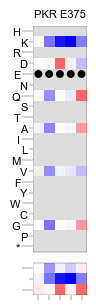

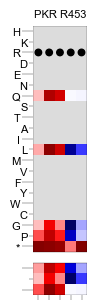

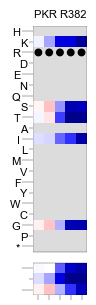

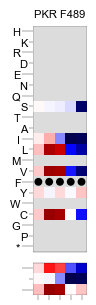

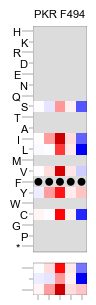

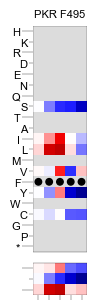

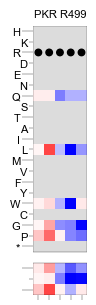

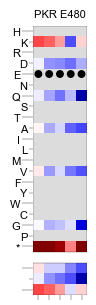

In [22]:
# plot parameters
plt.rcParams['font.family'] = 'Arial'

def custom_cmap(cmap_name, center, vmin, vmax):
    """Pulled from seaborn matrix.py to center cmap on WT value"""
    cmap = mpl.colormaps[cmap_name]
    under = cmap(-np.inf)
    over = cmap(np.inf)
    under_set = under != cmap(0)
    over_set = over != cmap(cmap.N - 1)

    vrange = max(vmax - center, center - vmin)
    normlize = mpl.colors.Normalize(center - vrange, center + vrange)
    cmin, cmax = normlize([vmin, vmax])
    cc = np.linspace(cmin, cmax, 256)
    cmap = mpl.colors.ListedColormap(cmap(cc))
    cmap.set_bad(color='gainsboro')
    if under_set:
        cmap.set_under(under)
    if over_set:
        cmap.set_over(over)

    return cmap

['K3Δ58', 'VACV K3', 'VARV C3', 'TPV K3', 'MYXV M156R', 'RCVZ vIF2α']
k3_names = ['K3Δ58', 'Vaccinia K3', 'Variola K3', 'Tanapox K3', 'Myxoma K3', 'Ranavirus K3']

def plot_residue_miniheatmap(
    df,
    focus_site,
    save_dir=save_dir,
    conditions=('K3Δ58', 'VACV K3', 'VARV C3', 'TPV K3', 'RCVZ vIF2α'),
    condition_names=('K3Δ58', 'Vaccinia K3', 'Variola K3', 'Tanapox K3', 'Ranavirus vIF2α'),
    cmap_color='seismic_r',
    scale_scope='condition',
    show_wt_circles=True,
    stagger_labels=True,
    font_size=8,
):
    
    conditions = list(conditions)
    condition_names = list(condition_names)

    # amino-acid row order (same as the big heatmaps)
    aa_list = ['H', 'K', 'R', 'D', 'E', 'N', 'Q', 'S', 'T', 'A', 'I',
               'L', 'M', 'V', 'F', 'Y', 'W', 'C', 'G', 'P', '*']
    aa_no_stops = [a for a in aa_list if a != '*']
    summary_rows = ['Mean Missense', 'Max Missense', 'Min Missense']
    GAP_ROW = '__row_gap__'

    site_df = df.query('site == @focus_site')
    if site_df.empty:
        raise ValueError(f'No rows found for site {focus_site}')
    wt_aa = site_df['wt_aa'].dropna().iloc[0]

    # --- Value matrix: rows = AA variants, cols = virus conditions ---
    data = pd.DataFrame(index=aa_list, columns=conditions, dtype=float)
    for cond in conditions:
        s = (site_df.query('k3 == @cond and pkr != "PKR-WT"')
                    .set_index('var_aa')['auc_mean'])
        for aa in aa_list:
            data.loc[aa, cond] = s.get(aa, np.nan)

    # --- Summary rows (missense only, WT row is NaN so it's skipped) ---
    missense = data.loc[aa_no_stops]
    summary = pd.DataFrame(index=summary_rows, columns=conditions, dtype=float)
    summary.loc['Mean Missense'] = missense.mean(axis=0, skipna=True)
    summary.loc['Max Missense'] = missense.max(axis=0, skipna=True)
    summary.loc['Min Missense'] = missense.min(axis=0, skipna=True)

    # --- Stack with a white gap row above the summaries ---
    gap = pd.DataFrame(index=[GAP_ROW], columns=conditions, dtype=float)
    full = pd.concat([data, gap, summary])
    row_labels = list(full.index)
    n_rows, n_cols = len(row_labels), len(conditions)

    # --- Per-virus colormap + normalization (each column on its own scale) ---
    cmaps, norms, scale = {}, {}, {}
    for cond in conditions:
        cond_all = df.query('k3 == @cond')
        center = cond_all.query('pkr == "PKR-WT"')['auc_mean'].iloc[0]
        if scale_scope == 'site':
            vmin = np.nanmin(data[cond].values.astype(float))
            vmax = np.nanmax(data[cond].values.astype(float))
        else:  # 'condition' -> matches the full-length heatmaps
            vmin = cond_all['auc_mean'].min()
            vmax = cond_all['auc_mean'].max()
        cmaps[cond] = custom_cmap(cmap_color, center, vmin, vmax)  # your existing fn
        norms[cond] = mcolors.Normalize(vmin, vmax)
        scale[cond] = (vmin, vmax)

    # --- Figure ---
    plt.rcParams['font.family'] = 'Arial'
    fig, ax = plt.subplots(figsize=(6,3.5))
    gainsboro = mcolors.to_rgba('gainsboro')

    # --- Draw each cell, colored on its own column's scale ---
    for i, rlabel in enumerate(row_labels):
        for j, cond in enumerate(conditions):
            if rlabel == GAP_ROW:
                color = (1, 1, 1, 1)                       # white spacer
            else:
                val = full.loc[rlabel, cond]
                color = gainsboro if pd.isna(val) else cmaps[cond](norms[cond](val))
            ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor=color,
                                       edgecolor='none', zorder=1))

    ax.set_xlim(0, n_cols)
    ax.set_ylim(n_rows, 0)   # row 0 at the top
    ax.set_aspect('equal')

    # --- WT identity circles (WT-AA row, one per virus column) ---
    if show_wt_circles and wt_aa in row_labels:
        wt_i = row_labels.index(wt_aa)
        for j in range(n_cols):
            ax.add_patch(plt.Circle((j + 0.5, wt_i + 0.5), 0.3,
                                    color='black', fill=True, zorder=4))

    # --- Section outlines: AA block + summary block (0.2 pt) ---
    gap_i = row_labels.index(GAP_ROW)
    for (r0, r1) in [(0, gap_i - 1), (gap_i + 1, n_rows - 1)]:
        ax.add_patch(plt.Rectangle((0, r0), n_cols, (r1 - r0 + 1),
                                   fill=False, edgecolor='black',
                                   linewidth=0.2, zorder=5))
    for spine in ax.spines.values():
        spine.set_visible(False)

    # --- Y ticks (AA + summary labels, gap row hidden) ---
    y_labels = ['' if r == GAP_ROW else r for r in row_labels]
    summary_rows = ['Mean Missense', 'Max Missense', 'Min Missense']  # already defined above
    y_labels = ['' if r in ([GAP_ROW] + summary_rows) else r for r in row_labels]
    ax.set_yticks(np.arange(n_rows) + 0.5)
    ax.set_yticklabels(y_labels, rotation=0, fontsize=font_size)
    ax.tick_params(axis='both', which='both', width=0.25)

    if stagger_labels:
        summary_offsets = {'Mean Missense': -2, 'Max Missense': 3, 'Min Missense': -2}
        aa_counter = 0
        for i, tick in enumerate(ax.yaxis.get_major_ticks()):
            rlabel = row_labels[i]
            if rlabel == GAP_ROW:
                tick.tick1line.set_markersize(0)
                continue
            tick.tick1line.set_markersize(8 if i % 2 == 0 else 3)
            dx = None
            if rlabel in aa_list:
                dx = -2 if aa_counter % 2 == 0 else 3
                aa_counter += 1
            elif rlabel in summary_offsets:
                dx = summary_offsets[rlabel]
            if dx is not None:
                lab = tick.label1
                lab.set_transform(offset_copy(lab.get_transform(), fig=fig,
                                              x=dx, y=0, units='points'))

    # --- X ticks (virus names) ---
    ax.set_xticks(np.arange(n_cols) + 0.5)
    #ax.set_xticklabels(condition_names, rotation=45, ha='right', fontsize=font_size)
    ax.set_xticklabels([''] * n_cols)
    ax.set_title(f'PKR {wt_aa}{focus_site}', fontsize=font_size, pad=6)

    # --- One colorbar per virus (each shows its own scale) ---


    # --- Save ---
    plot_name = f'residue-miniheatmap_no-labels_{wt_aa}{focus_site}.svg'
    out = os.path.join(save_dir, plot_name)
    fig.savefig(out, bbox_inches='tight', format='svg', transparent=True)
    plt.show()
    return fig, ax


# Example — modular on the focus residue:
for i in [375,453,382,489,494,495,499,480]:
    plot_residue_miniheatmap(df, i)